## **Case Study**

## **Logistic Regression for Customer churm prediction**

### Q1 **Design a machine learning alogorithm, Which will predict an employee will churm or not based on various <br>predictors**

In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler

### **Load the dataset and Display the first few rows of the dataset**

In [2]:
churn_data = pd.read_csv(r"C:\Users\LENOVO\Downloads\churn_data.csv")
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
churn_data.dtypes

customerID           object
tenure                int64
PhoneService         object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
churn_data['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [5]:
churn_data['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [6]:
churn_data['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [7]:
churn_data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
churn_data['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

## **Data Cleaning and preparation**

In [9]:
churn_data.shape

(7043, 9)

In [10]:
churn_data.isnull().sum()

customerID          0
tenure              0
PhoneService        0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Encode categorical variables**

In [12]:
label_encoder = {}
for column in churn_data.select_dtypes(include=['object']).columns:
    if column != 'customerID':
        label_encoder[column]=LabelEncoder()
        churn_data[column]=label_encoder[column].fit_transform(churn_data[column])

churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,0,0,1,2,29.85,2505,0
1,5575-GNVDE,34,1,1,0,3,56.95,1466,0
2,3668-QPYBK,2,1,0,1,3,53.85,157,1
3,7795-CFOCW,45,0,1,0,0,42.30,1400,0
4,9237-HQITU,2,1,0,1,2,70.70,925,1


## **Define the independent and dependent variables**

In [13]:
x = churn_data.drop(columns=['customerID','Churn'])
y = churn_data['Churn']
x.head()

,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,0,1,2,29.85,2505
1,34,1,1,0,3,56.95,1466
2,2,1,0,1,3,53.85,157
3,45,0,1,0,0,42.30,1400
4,2,1,0,1,2,70.70,925


In [14]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## **Split the data into training and test sets**

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [16]:
x_test.shape,y_test.shape

((1409, 7), (1409,))

In [17]:
y_train.shape,x_train.shape

((5634,), (5634, 7))

##  **Standardize the features**

In [18]:
scalar = StandardScaler()
X_train = scalar.fit_transform(x_train)
X_test = scalar.transform(x_test)

- The `transform` method is called on the test data `x_test`. This method uses the mean<br>and standard deviation computed from the training data to standardize the test data.<br>
- It's important to note that we only `fit` the scalar on training data and not on the test data. <br> This is to ensure that the the model is evaluated on data that is not biased by the test set statistics

In [19]:
X_test

array([[-1.28460467, -3.03422506, -0.83177379, ...,  0.40252821,
        -1.33162874, -0.64775556],
       [ 0.35323794,  0.32957344, -0.83177379, ..., -1.47094882,
        -1.31667194,  1.72630461],
       [ 0.80364466,  0.32957344,  1.5775905 , ...,  1.33926673,
        -1.51277218, -1.69588351],
       ...,
       [-0.62946762,  0.32957344,  0.37290835, ..., -1.47094882,
        -1.49449165, -0.21726497],
       [ 1.49972776, -3.03422506,  1.5775905 , ..., -0.5342103 ,
        -0.69513389, -0.37631322],
       [-1.28460467, -3.03422506, -0.83177379, ...,  1.33926673,
        -1.11392424, -0.30156054]], shape=(1409, 7))

## **Building  first logistic regression Model**

In [20]:
from sklearn.linear_model import LogisticRegression

# Intialize the model 
model = LogisticRegression()

# Train the model
model.fit(X_train,y_train)

# Make predictions
y_pred = model.predict(X_test)

In [21]:
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [22]:
y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
6366    0
315     0
2439    0
5002    0
1161    1
Name: Churn, Length: 1409, dtype: int64

## **Recursive Elimination Feature(REF)**

In [23]:
from sklearn.feature_selection import RFE

# Intialize the model for REF
rfe_model = LogisticRegression()

# Intialize REF with the model
rfe = RFE(estimator=rfe_model,n_features_to_select=5)

In [24]:
# Fit REF
rfe.fit(X_train,y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",5
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [25]:
# Get the Selected features
selected_features = rfe.support_

# Transform the datasets
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

# Retrain the model on the selected features
model.fit(X_train_rfe,y_train)

# Make predictions
y_pred_rfe = model.predict(X_test_rfe)

## **Model Evaluation Metrics - Exercise <br> various Model evaluation <br>Confusion Matrix and accuracy**

In [26]:
from sklearn.metrics import confusion_matrix , accuracy_score

# Generate the confusion matrix 
conf_matrix =  confusion_matrix(y_test,y_pred)
print('Confusion Matrix:\n',conf_matrix)

# Calculate accuracy
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy:',accuracy)

Confusion Matrix:
 [[938  98]
 [175 198]]
Accuracy: 0.8062455642299503


In [27]:
from sklearn.metrics import confusion_matrix , accuracy_score

# Generate the confusion matrix 
conf_matrix =  confusion_matrix(y_test,y_pred_rfe)
print('Confusion Matrix:\n',conf_matrix)

# Calculate accuracy
accuracy = accuracy_score(y_test,y_pred_rfe)
print('Accuracy:',accuracy)

Confusion Matrix:
 [[937  99]
 [170 203]]
Accuracy: 0.8090844570617459


## **Metrices Beyound Accuracy: Sensitivity & specificity**

In [28]:
# Calculate senstivity (recall) and specificity
from sklearn.metrics import recall_score

# Senstivity(recall)
senstivity = recall_score(y_test,y_pred_rfe)
print('Senstivity: ',senstivity)

# Specificity
tn,fp,fn,tp = confusion_matrix(y_test,y_pred_rfe).ravel()
specificity = tn/(tn+fp)
print('Specificity: ',specificity)

Senstivity:  0.5442359249329759
Specificity:  0.9044401544401545


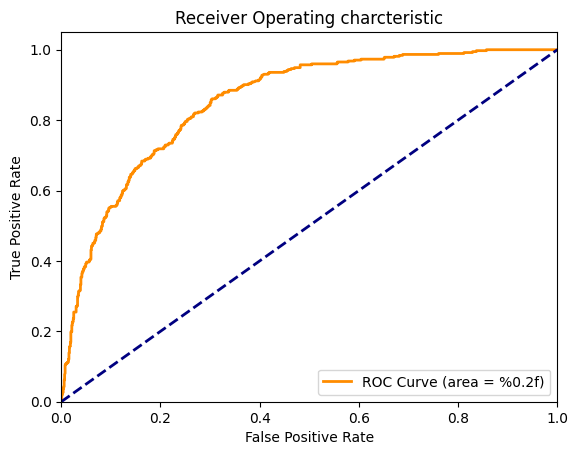

In [30]:
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_auc_score,roc_curve

# Calculate ROC curve 
fpr,tpr ,threshold = roc_curve(y_test,model.predict_log_proba(X_test_rfe)[:,1])
plt.figure()
plt.plot(fpr,tpr,color='darkorange',lw=2,label='ROC Curve (area = %0.2f)')

plt.plot([0,1],[0,1],color = 'navy',lw = 2 ,linestyle = '--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating charcteristic')
plt.legend(loc= 'lower right')
plt.show()

## **Calculate Precision and recall**

In [31]:
from sklearn.metrics import  precision_score
precision  = precision_score(y_test,y_pred_rfe)
recall = recall_score(y_test,y_pred_rfe)

print('Precision: ',precision)
print('Recall: ',recall)

Precision:  0.6721854304635762
Recall:  0.5442359249329759
